<a href="https://colab.research.google.com/github/YaninaK/predictive-maintenance/blob/main/notebooks/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sys
import os

sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), "src", "predictive_maintenance"))

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import missingno as msno

from data.make_dataset import load_X
from data.EDA_utilities import get_y_summary, load_y
from data.ethalon_periods import (
    select_ethalon_periods, get_pca_components, generate_ethalon_dataset,
)
from data.stoppages import get_M1_dataset
from data.anomalies import get_M3_dataset, generate_targets
from data.train_test_datasets import (
    combine_test_intervals, generate_test_dataset
)
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Загрузка данных

In [9]:
messages = pd.read_parquet(PATH + FOLDER + "messages_unified.parquet")

print(f'messages.shape = {messages.shape}\n')
messages.head(2)

messages.shape = (981, 11)



,МАШИНА,ИМЯ_МАШИНЫ,ТЕХ_МЕСТО,НАЗВАНИЕ_ТЕХ_МЕСТА,ВИД_СООБЩЕНИЯ,ОПИСАНИЕ,ДАТА_НАЧАЛА_НЕИСПРАВНОСТИ,ДАТА_УСТРАНЕНИЯ_НЕИСПРАВНОСТИ,ТЕКСТ_ГРУППЫ_КОДОВ,equipment,unified_name
390,AA2/006-006,ЭКСГАУСТЕР А/М №9,AA2/006-006-002-008,ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №9,M3,неисправен двигатель,2019-01-21 00:00:00,2019-02-25,None,9,ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №
391,CH-AGP-AG2/011-005,ЭКСГАУСТЕР А/М №9,CH-AGP-AG2/011-005-002,МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ. №9,M3,неисправен двигатель,2019-01-21 12:26:08,2019-02-25,None,9,МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ_ №


In [10]:
unified_tech_places = pd.read_parquet(
    PATH + FOLDER + "unified_tech_places.parquet"
)
print(f'unified_tech_places.shape = {unified_tech_places.shape}\n')
unified_tech_places.head(2)

unified_tech_places.shape = (175, 3)



,equipment,description,unified_name
0,9,9_ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №9,ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №
1,9,9_МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ_ №9,МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ_ №


In [11]:
i = 4
X_train = load_X(i, path=PATH)

print(f'X_train.shape = {X_train.shape}\n')
X_train.head(2)

X_train.shape = (1555839, 16)



,4 ВИБРАЦИЯ НА ОПОРЕ 1,4 ВИБРАЦИЯ НА ОПОРЕ 2,4 ВИБРАЦИЯ НА ОПОРЕ 3,4 ВИБРАЦИЯ НА ОПОРЕ 3 ПРОДОЛЬНАЯ,4 ВИБРАЦИЯ НА ОПОРЕ 4,4 ВИБРАЦИЯ НА ОПОРЕ 4 ПРОДОЛЬНАЯ,4 ДАВЛЕНИЕ МАСЛА В СИСТЕМЕ,4 ТЕМПЕРАТУРА МАСЛА В МАСЛОБЛОКЕ,4 ТЕМПЕРАТУРА МАСЛА В СИСТЕМЕ,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 1,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 2,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 3,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 4,4 ТОК РОТОРА 1,4 ТОК РОТОРА 2,4 ТОК СТАТОРА
dt,,,,,,,,,,,,,,,,
2019-01-16 13:21:00,1.562818,0.743243,0.656307,1.632879,3.274178,0.738962,119.375153,40.369577,33.369792,41.427914,39.751736,39.862907,44.595902,363.321395,363.321395,243.301550
2019-01-16 13:22:00,1.557138,0.737997,0.660079,1.621047,3.220093,0.725388,119.395694,40.332575,33.506294,41.509807,39.725041,39.953993,44.736912,362.849194,362.849194,242.917778


In [12]:
y = load_y(i, path=PATH)

print(f'y.shape = {y.shape}\n')
y.head(2)

y.shape = (1555839, 23)



,4_ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№4 Т_1,4_ГСМ ЭКСГ_ №4,4_ЗАДВИЖКА ЭКСГ_ №4,4_ЗАП_ И РЕГ_ АРМАТУРА ЭКСГ_№4,4_КЛ1 ТР№4 ДО ЭД ЭКСГАУСТЕРА №4,4_КЛ2 ТР№4 ДО ЭД ЭКСГАУСТЕРА №4,4_МАСЛОНАСОС РАБОЧИЙ ЭКСГ_ №4,4_МАСЛООХЛАДИТЕЛЬ М-05-1 ЭКСГ_ №4,4_МАСЛОПРОВОДЫ ЭКСГ №4,4_ПОДШИПНИК ОПОРНО-УПОРНЫЙ ЭКСГ_ №4,...,4_РЕДУКТОР ГАЗ_ ЗАДВИЖКИ ЭКСГ_ №4,4_РОТОР ЭКСГ_ №4,4_ТИРИСТ_ ВОЗБУДИТЕЛЬ ВТ-РЭМ-400 ЭКСГ4 ВУ1,4_ТР-Р ТМ-4000-10/6 ЭКСГ_ №4,4_ТСМТ-101-010-50М-400 ТЕРМОПР_ПОДШ_Т_1,4_УЛИТА ЭКСГ_ №4,4_ЭКСГАУСТЕР А/М №4,4_ЭЛ/ДВИГАТЕЛЬ ГАЗ_ ЗАДВИЖКИ ЭКСГ_ №4,4_ЭЛЕКТРОАППАРАТУРА ЭКСГ_ №4,4_ЭЛЕКТРОДВИГАТЕЛЬ ДСПУ-140-84-4 ЭКСГ_ №4
dt,,,,,,,,,,,,,,,,,,,,,
2019-01-16 13:21:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-16 13:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
test_intervals = pd.read_parquet(
    PATH + FOLDER + "test_intervals.parquet"
).sort_values(by='start').reset_index(drop=True)

print(f'test_intervals.shape = {test_intervals.shape}\n')
test_intervals.head(2)

test_intervals.shape = (189, 4)



,start,finish,machine,tm
0,2022-01-01 10:54:53,2022-01-01 16:43:39,NaN,NaN
1,2022-01-02 12:26:42,2022-01-02 15:16:06,NaN,NaN


In [14]:
X_test = load_X(i, path=PATH, prefix="X_test")

print(f'X_test.shape = {X_test.shape}\n')
X_test.head(2)

X_test.shape = (668161, 16)



,4 ВИБРАЦИЯ НА ОПОРЕ 1,4 ВИБРАЦИЯ НА ОПОРЕ 2,4 ВИБРАЦИЯ НА ОПОРЕ 3,4 ВИБРАЦИЯ НА ОПОРЕ 3 ПРОДОЛЬНАЯ,4 ВИБРАЦИЯ НА ОПОРЕ 4,4 ВИБРАЦИЯ НА ОПОРЕ 4 ПРОДОЛЬНАЯ,4 ДАВЛЕНИЕ МАСЛА В СИСТЕМЕ,4 ТЕМПЕРАТУРА МАСЛА В МАСЛОБЛОКЕ,4 ТЕМПЕРАТУРА МАСЛА В СИСТЕМЕ,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 1,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 2,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 3,4 ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 4,4 ТОК РОТОРА 1,4 ТОК РОТОРА 2,4 ТОК СТАТОРА
dt,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.758333,1.180000,0.360,1.906000,2.075,1.416667,134.444,NaN,31.235,42.595,43.540,30.830,34.394,247.51,247.51,271.153333
2022-01-01 00:01:00,0.738000,1.211667,0.374,1.913333,1.780,1.291667,134.420,33.26,31.100,42.595,43.405,31.235,34.610,247.39,247.39,271.195000


## 2. EDA

### 2.1. Разметка

#### 2.1.1 Messages

In [15]:
t0 = pd.Timestamp("1970-01-01")
period = pd.Timedelta('1T')
messages['start_M'] = (
    (messages['ДАТА_НАЧАЛА_НЕИСПРАВНОСТИ']  - t0) // period * period + t0
)
messages.loc[536, 'start_M'] = pd.Timestamp('2019-04-28 10:05:00')
messages.head(2)

,МАШИНА,ИМЯ_МАШИНЫ,ТЕХ_МЕСТО,НАЗВАНИЕ_ТЕХ_МЕСТА,ВИД_СООБЩЕНИЯ,ОПИСАНИЕ,ДАТА_НАЧАЛА_НЕИСПРАВНОСТИ,ДАТА_УСТРАНЕНИЯ_НЕИСПРАВНОСТИ,ТЕКСТ_ГРУППЫ_КОДОВ,equipment,unified_name,start_M
390,AA2/006-006,ЭКСГАУСТЕР А/М №9,AA2/006-006-002-008,ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №9,M3,неисправен двигатель,2019-01-21 00:00:00,2019-02-25,None,9,ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №,2019-01-21 00:00:00
391,CH-AGP-AG2/011-005,ЭКСГАУСТЕР А/М №9,CH-AGP-AG2/011-005-002,МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ. №9,M3,неисправен двигатель,2019-01-21 12:26:08,2019-02-25,None,9,МАСЛОСТАНЦИЯ ЖИДКОЙ СМАЗКИ ЭКСГ_ №,2019-01-21 12:26:00


In [16]:
messages.shape

(981, 12)

In [17]:
messages['ВИД_СООБЩЕНИЯ'].value_counts()

M3    898
M1     83
Name: ВИД_СООБЩЕНИЯ, dtype: int64

* M1 - остановки эксгаустеров
* M3 - аномалии в работе эксгаустеров

##### M1. Oстановки эксгаустеров

In [18]:
pd.pivot_table(
    messages[messages['ВИД_СООБЩЕНИЯ'] == 'M1'],
    index='ТЕКСТ_ГРУППЫ_КОДОВ',
    columns='equipment',
    values='ОПИСАНИЕ',
    aggfunc='count',
    margins=True,
)

equipment,4,5,6,7,8,9,All
ТЕКСТ_ГРУППЫ_КОДОВ,,,,,,,
ВНЕШНИЕ ОРГАНИЗАЦИИ,NaN,1.0,NaN,NaN,1.0,NaN,2
ТЕХНИЧЕСКИЕ НЕПЛАНОВЫЕ,17.0,19.0,6.0,11.0,12.0,4.0,69
ТЕХНИЧЕСКИЕ ПЛАНОВЫЕ,2.0,3.0,1.0,2.0,NaN,NaN,8
ТЕХНОЛОГИЧЕСКИЕ НЕПЛАНОВЫЕ,1.0,NaN,NaN,1.0,1.0,NaN,3
ТЕХНОЛОГИЧЕСКИЕ ПЛАНОВЫЕ,NaN,NaN,1.0,NaN,NaN,NaN,1
All,20.0,23.0,8.0,14.0,14.0,4.0,83


Прогнозировать имеет смысл только на неплановые остановки оборудования: ТЕХНИЧЕСКИЕ НЕПЛАНОВЫЕ и ТЕХНОЛОГИЧЕСКИЕ НЕПЛАНОВЫЕ.

In [19]:
cond_1 = messages['ТЕКСТ_ГРУППЫ_КОДОВ'] == 'ТЕХНИЧЕСКИЕ НЕПЛАНОВЫЕ'
cond_2 = messages['ТЕКСТ_ГРУППЫ_КОДОВ'] == 'ТЕХНОЛОГИЧЕСКИЕ НЕПЛАНОВЫЕ'

pd.pivot_table(
    messages[cond_1 | cond_2],
    index='unified_name',
    columns='equipment',
    values='ДАТА_НАЧАЛА_НЕИСПРАВНОСТИ',
    aggfunc='count',
    margins=True,
)

equipment,4,5,6,7,8,9,All
unified_name,,,,,,,
ЗАДВИЖКА ЭКСГ_ №,4.0,1.0,6.0,NaN,NaN,NaN,11
КОРПУС ЭКСГ_ №,NaN,NaN,NaN,2.0,NaN,NaN,2
ПОДШИПНИК ОПОРНО-УПОРНЫЙ ЭКСГ_ №,1.0,NaN,NaN,NaN,NaN,NaN,1
ПОДШИПНИК ОПОРНЫЙ №1,NaN,5.0,NaN,NaN,NaN,NaN,5
ПОДШИПНИК ОПОРНЫЙ №2,3.0,NaN,NaN,1.0,NaN,NaN,4
РОТОР ЭКСГ_ №,5.0,4.0,NaN,4.0,7.0,NaN,20
ТИРИСТ_ ВОЗБУДИТЕЛЬ ВТ-РЭМ-400 ЭКСГ ВУ1,NaN,4.0,NaN,NaN,NaN,NaN,4
ТИРИСТ_ ВОЗБУДИТЕЛЬ ВТ-РЭМ-400 ЭКСГ ВУ2,NaN,1.0,NaN,NaN,NaN,NaN,1
ТИРИСТОРНЫЙ ВОЗБУДИТЕЛЬ ТВ-400 ЭКСГ ВУ1,NaN,NaN,NaN,NaN,2.0,NaN,2


In [20]:
unified_tech_places['unified_name'].nunique()

51

* Инфомация о неплановых остановках доступна только по 14 техническим местам из 51. Больше половины остановок произошло из-за неполадок с ротором, задвижкой и электродвигателем.

* Причины остановок между эксгаустерами существенно отличаются.

* Наиболшее число остановок на четвертом и пятом эксгаустерах, наименьшее - на шестом и девятом.

##### M3. Аномалии в работе эксгаустеров

In [21]:
pd.pivot_table(
    messages[messages['ВИД_СООБЩЕНИЯ'] == 'M3'],
    index='unified_name',
    columns='equipment',
    values='ДАТА_НАЧАЛА_НЕИСПРАВНОСТИ',
    aggfunc='count',
    margins=True,
)

equipment,4,5,6,7,8,9,All
unified_name,,,,,,,
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_1,1.0,2.0,NaN,NaN,NaN,1.0,4
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_2,NaN,3.0,NaN,1.0,2.0,NaN,6
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_3,NaN,4.0,NaN,4.0,2.0,NaN,10
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_4,NaN,NaN,NaN,1.0,2.0,NaN,3
ГСМ ЭКСГ_ №,5.0,5.0,NaN,5.0,6.0,3.0,24
ДВИГАТЕЛЬ ПУСКОВОГО МАСЛОНАСОСА ЭКСГ_ №,NaN,2.0,NaN,NaN,NaN,NaN,2
ЗАДВИЖКА ЭКСГ_ №,12.0,22.0,12.0,8.0,12.0,2.0,68
ЗАП_ И РЕГ_ АРМАТУРА ЭКСГ_№,1.0,NaN,NaN,NaN,NaN,NaN,1
ЗАПОРНАЯ АРМАТУРА ЭКСГАУСТЕРА №,NaN,3.0,NaN,NaN,2.0,1.0,6


* Больше половины всех аномалий зафиксировано в корпусах, роторах, редукторах, электродвигателях и задвижках эксгаустеров.
* Больше половины неполадок с корпусами приходилось на шестой и седьмой эксгаустеры.
* Больше половины неполадок с роторами произошли на седьмом и восьмом эксгаустерах.
* 40% аномалий в работе редукторов зафиксировано на четвертом эксгаустере.
* 32% аномалий в работе электродвигателей и 35% - в работе задвижек случились на пятом эксгаустере.

In [22]:
cond_1 = messages['ВИД_СООБЩЕНИЯ'] == 'M3'
cond_2 = messages['ДАТА_УСТРАНЕНИЯ_НЕИСПРАВНОСТИ'].isnull()

messages[cond_1 & cond_2].shape

(130, 12)

* У 130 аномалий из 898 нет данных об времени устранения неисправности.

#### 2.1.2. Анализ разметки остановок и аномалий на y_train

In [23]:
y_spec_1 = pd.pivot_table(
    unified_tech_places,
    index='unified_name',
    columns='equipment',
    values='description',
    aggfunc='count',
    margins=True,
)
print(f'y_spec_1.shape = {y_spec_1.shape}\n')
y_spec_1

y_spec_1.shape = (52, 7)



equipment,4,5,6,7,8,9,All
unified_name,,,,,,,
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_1,1.0,1.0,NaN,NaN,NaN,1.0,3
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_2,NaN,1.0,1.0,1.0,1.0,NaN,4
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_3,NaN,1.0,1.0,1.0,1.0,NaN,4
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_4,NaN,NaN,NaN,1.0,1.0,NaN,2
ГАЗОВАЯ ЗАДВИЖКА ЭКСГАУСТЕРА А/М №,NaN,1.0,1.0,NaN,NaN,NaN,2
ГСМ ЭКСГ_ №,1.0,1.0,NaN,1.0,1.0,1.0,5
ДВИГАТЕЛЬ ПУСКОВОГО МАСЛОНАСОСА ЭКСГ_ №,NaN,1.0,1.0,NaN,NaN,1.0,3
ДВИГАТЕЛЬ РЕЗЕРВНОГО МАСЛОНАСОСА ЭКСГ_№,NaN,1.0,NaN,NaN,NaN,NaN,1
ЗАДВИЖКА ЭКСГ_ №,1.0,1.0,1.0,1.0,1.0,1.0,6


* Разметка на y_train доступна менее чем по 60% технических мест.

In [24]:
regenerate = False
if regenerate:
  y_summary = get_y_summary(unified_tech_places, path=PATH)
  y_summary.to_parquet(PATH + FOLDER + "y_summary.parquet", compression="gzip")
else:
  y_summary = pd.read_parquet(PATH + FOLDER + "y_summary.parquet")

In [25]:
y_spec_2 = pd.pivot_table(
    y_summary,
    index='unified_name',
    columns='equipment',
    values='start_M',
    aggfunc='count',
    margins=True,
)
print(f'y_spec_2.shape = {y_spec_2.shape}\n')
y_spec_2

y_spec_2.shape = (49, 7)



equipment,4,5,6,7,8,9,All
unified_name,,,,,,,
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_1,1.0,1.0,NaN,NaN,NaN,1.0,3
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_2,NaN,2.0,NaN,1.0,2.0,NaN,5
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_3,NaN,1.0,NaN,3.0,1.0,NaN,5
ВК 310С ВИБРОПРЕОБРАЗОВАТЕЛЬ ЭКСГ_№ Т_4,NaN,NaN,NaN,1.0,1.0,NaN,2
ГАЗОВАЯ ЗАДВИЖКА ЭКСГАУСТЕРА А/М №,NaN,1.0,1.0,NaN,NaN,NaN,2
ГСМ ЭКСГ_ №,5.0,1.0,NaN,5.0,5.0,3.0,19
ДВИГАТЕЛЬ ПУСКОВОГО МАСЛОНАСОСА ЭКСГ_ №,NaN,2.0,NaN,NaN,NaN,NaN,2
ЗАДВИЖКА ЭКСГ_ №,14.0,11.0,9.0,4.0,5.0,2.0,45
ЗАП_ И РЕГ_ АРМАТУРА ЭКСГ_№,1.0,NaN,NaN,NaN,NaN,NaN,1


In [26]:
no_label = set(y_spec_1.index) - set(y_spec_2.index)
no_label

{'ДВИГАТЕЛЬ РЕЗЕРВНОГО МАСЛОНАСОСА ЭКСГ_№',
 'РЕГУЛИРУЮЩАЯ АППАРАТУРА ЭКСГАУСТЕРА №',
 'ЭКСГАУСТЕР Н-8000 А/М №'}

* Аномалии работы двигателя резервного маслонасоса, эксгаустера Н-8000 (эксг 5) и регулирующей аппаратуры эксгаустера (эксг 7) не имеют разметки.
* Значительная часть разметки из messages не попала в y_train: 898 vs 395.
* Разметку для модели будем создавать на основе messages.

### 2.2. Пропуски в данных

#### 2.2.1. Пропуски в обучающей выборке

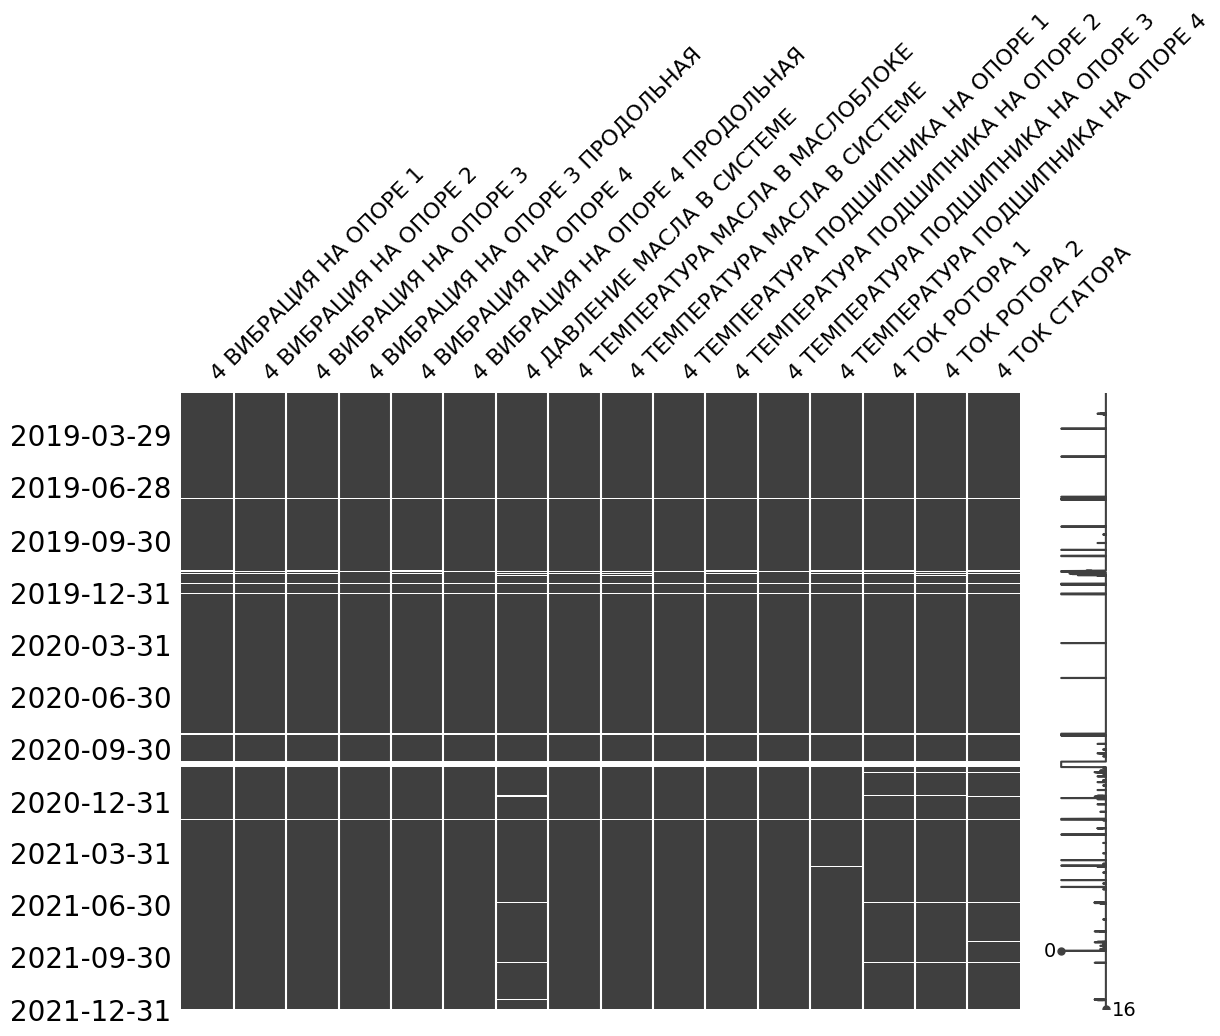

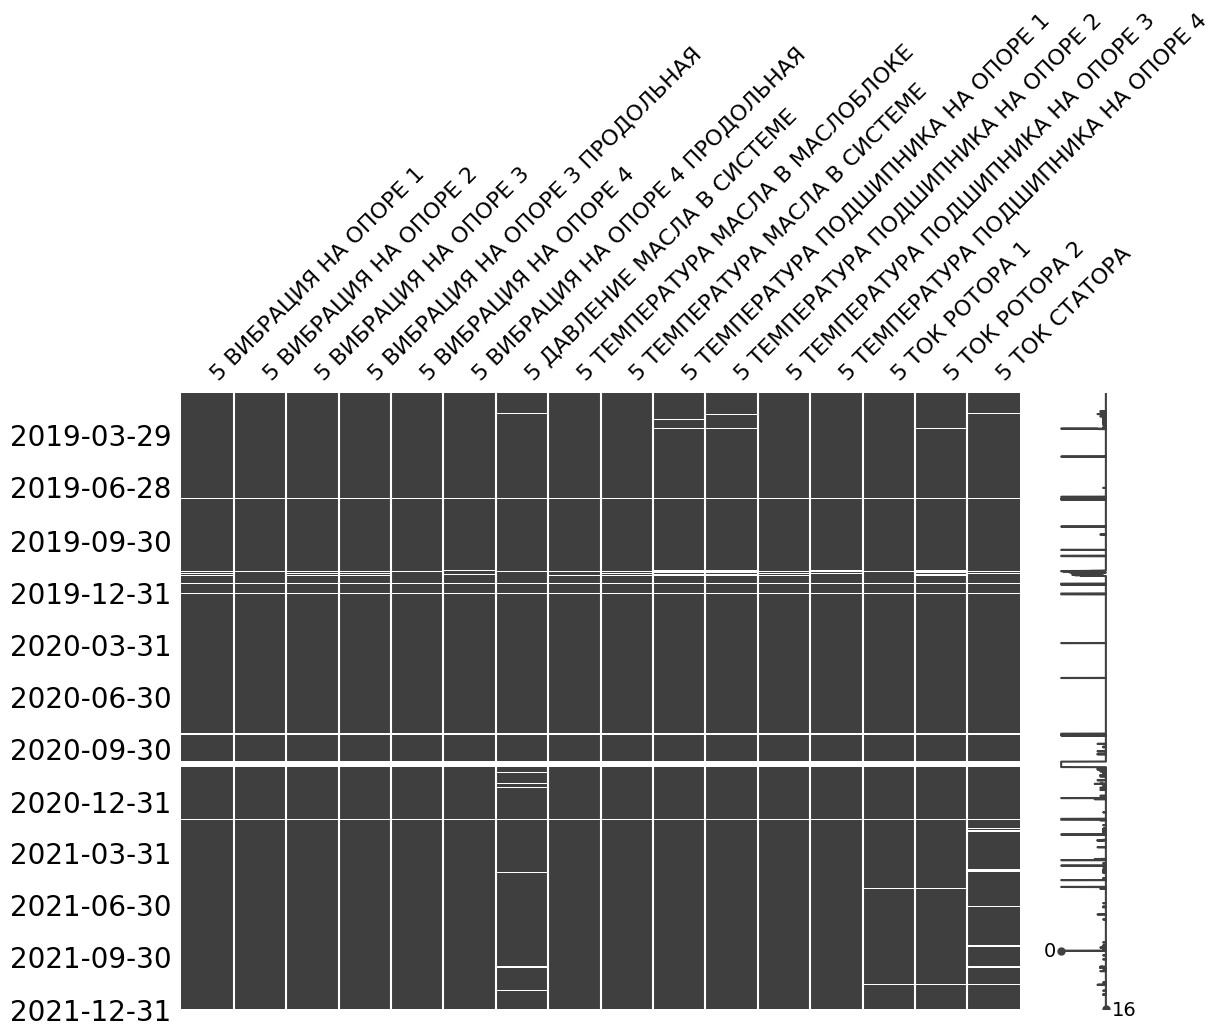

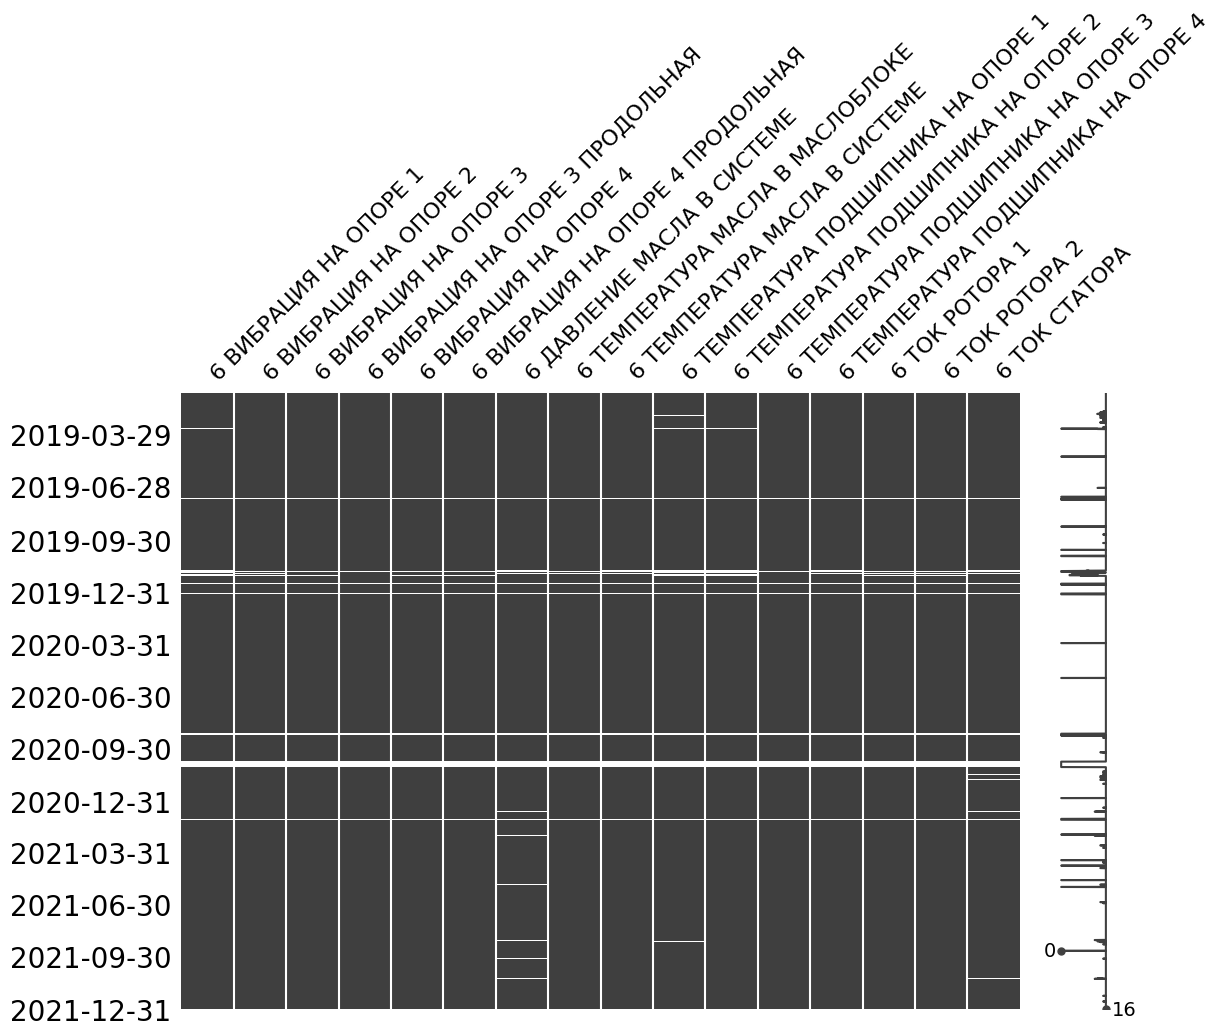

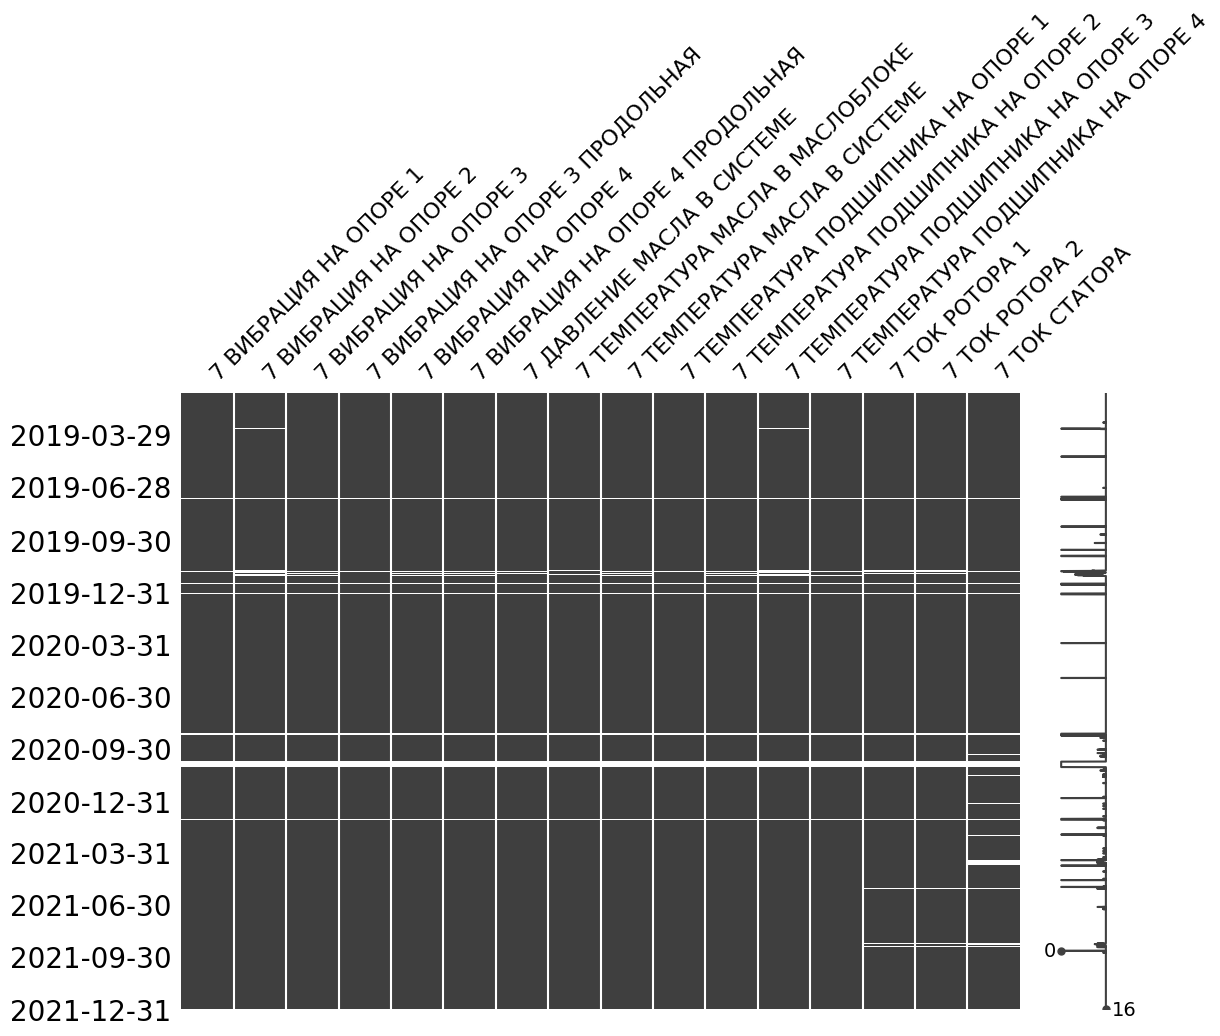

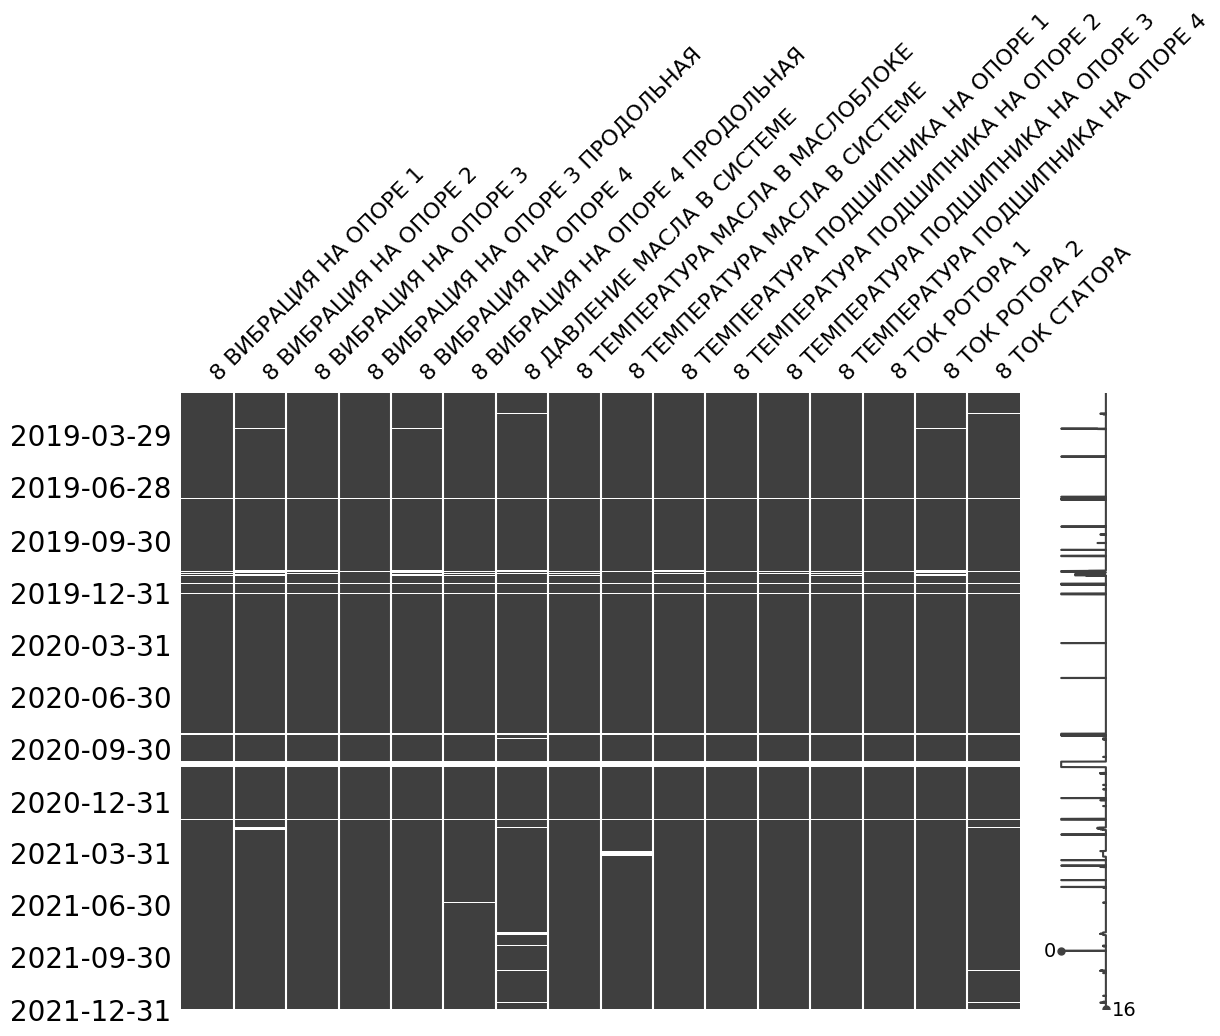

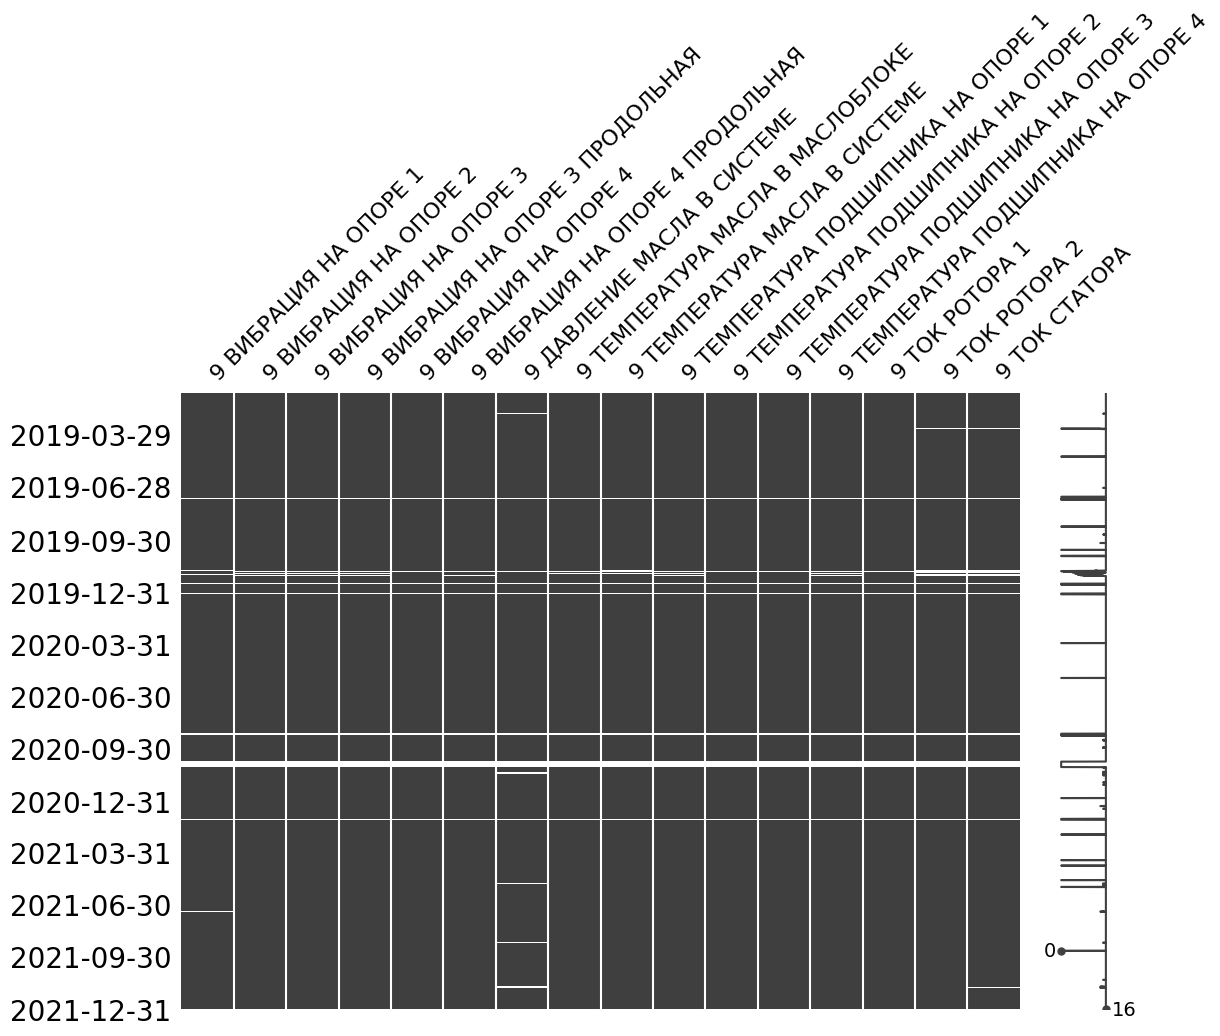

In [27]:
freq = "1H"
for equipment in range(4, 10):
  X_train = load_X(equipment, path=PATH).resample(freq).median()
  msno.matrix(X_train, freq='BQ', figsize=(12, 8));

#### 2.2.2. Пропуски в тестовой выборке

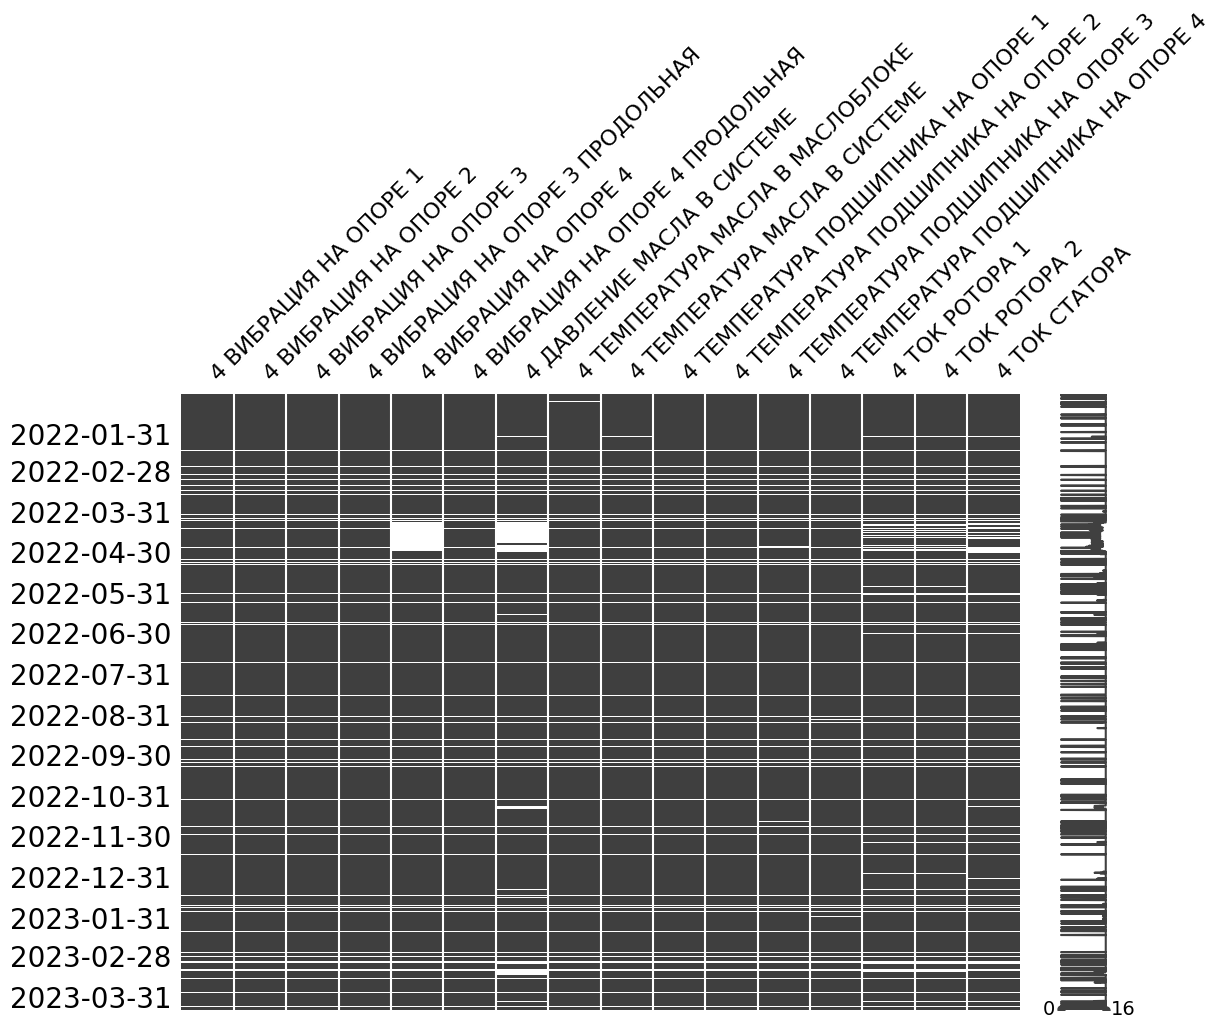

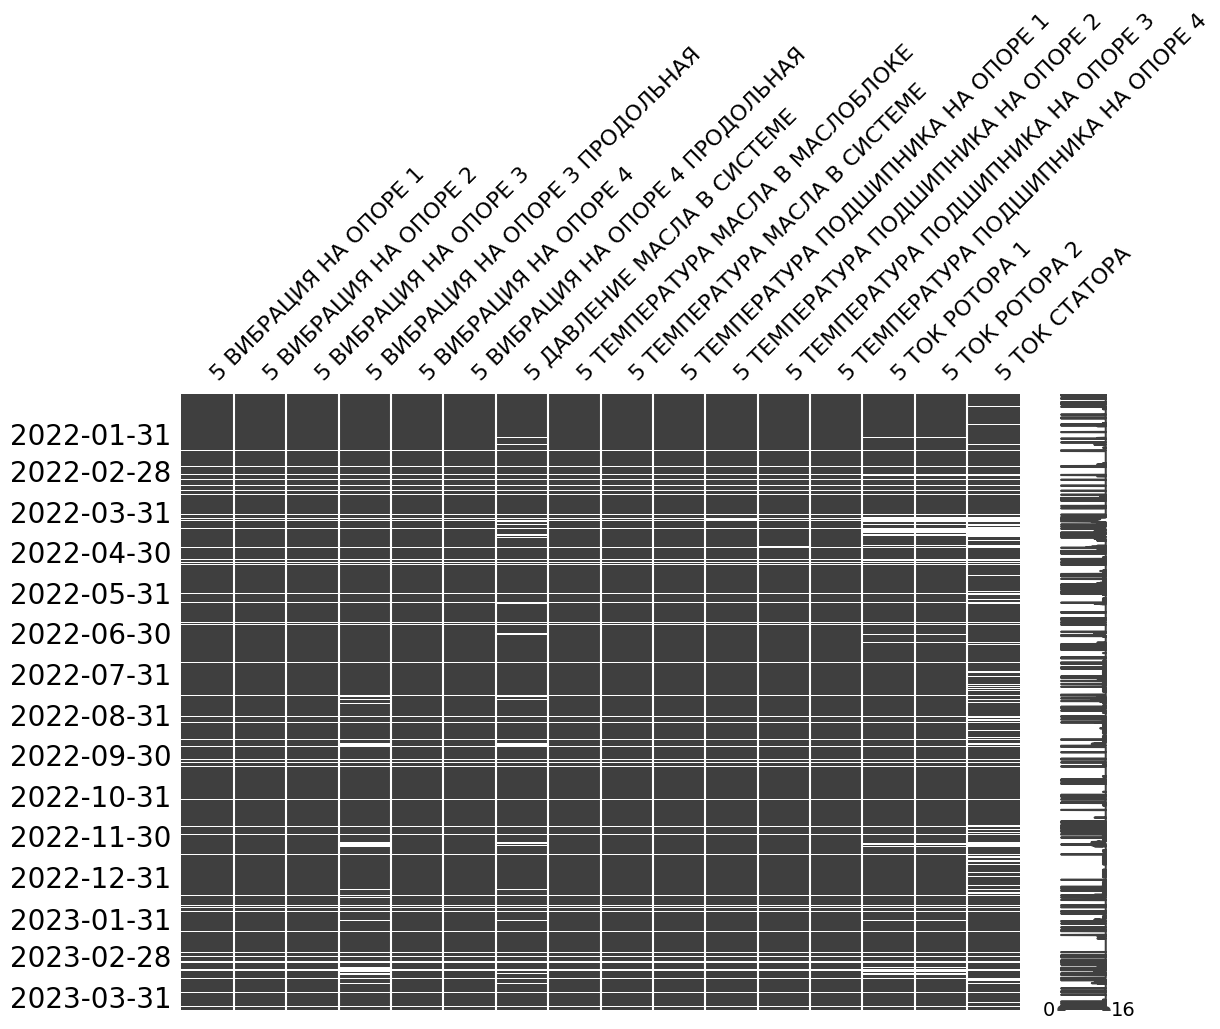

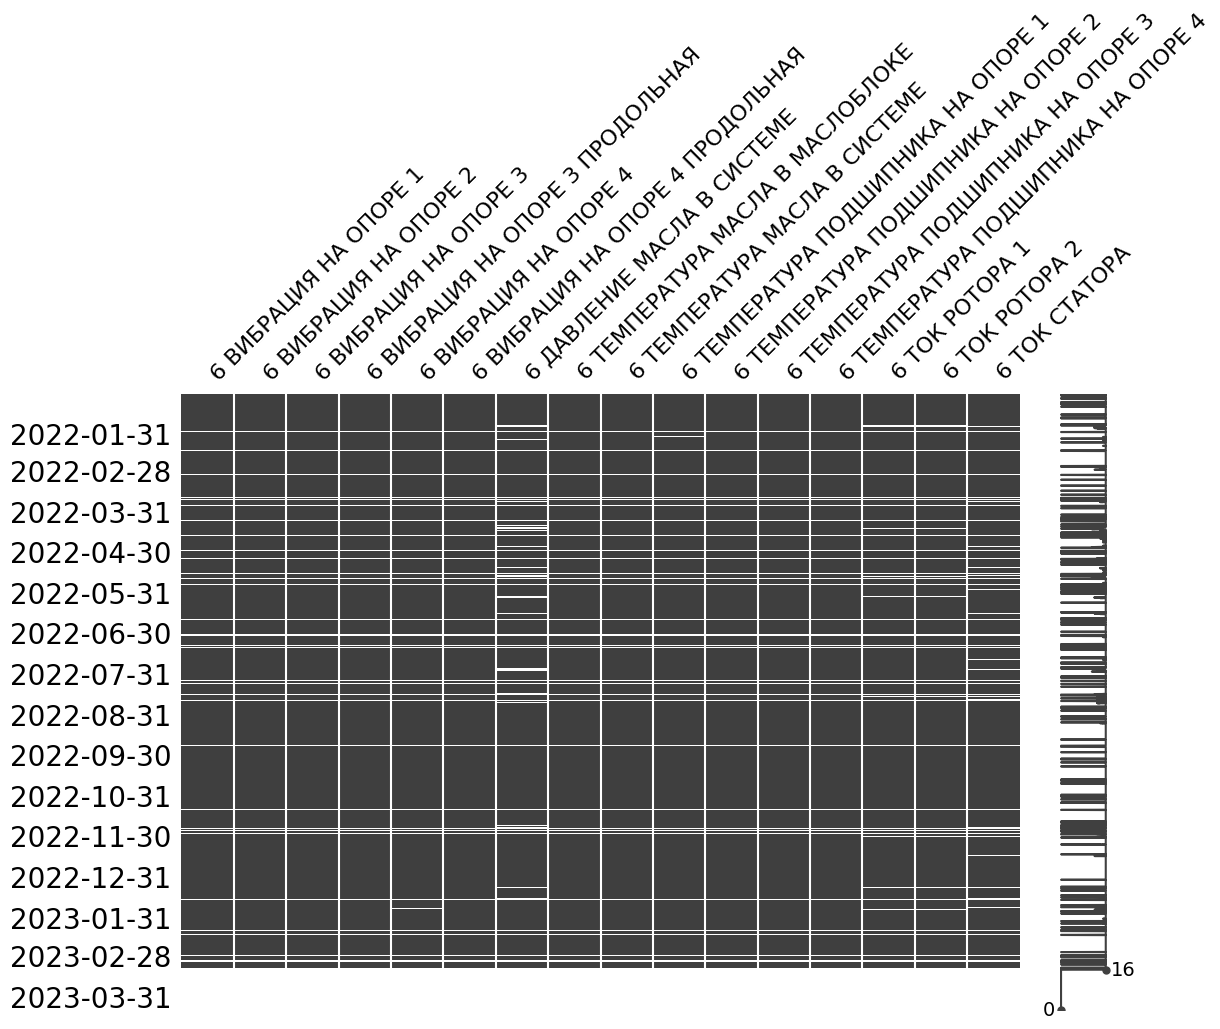

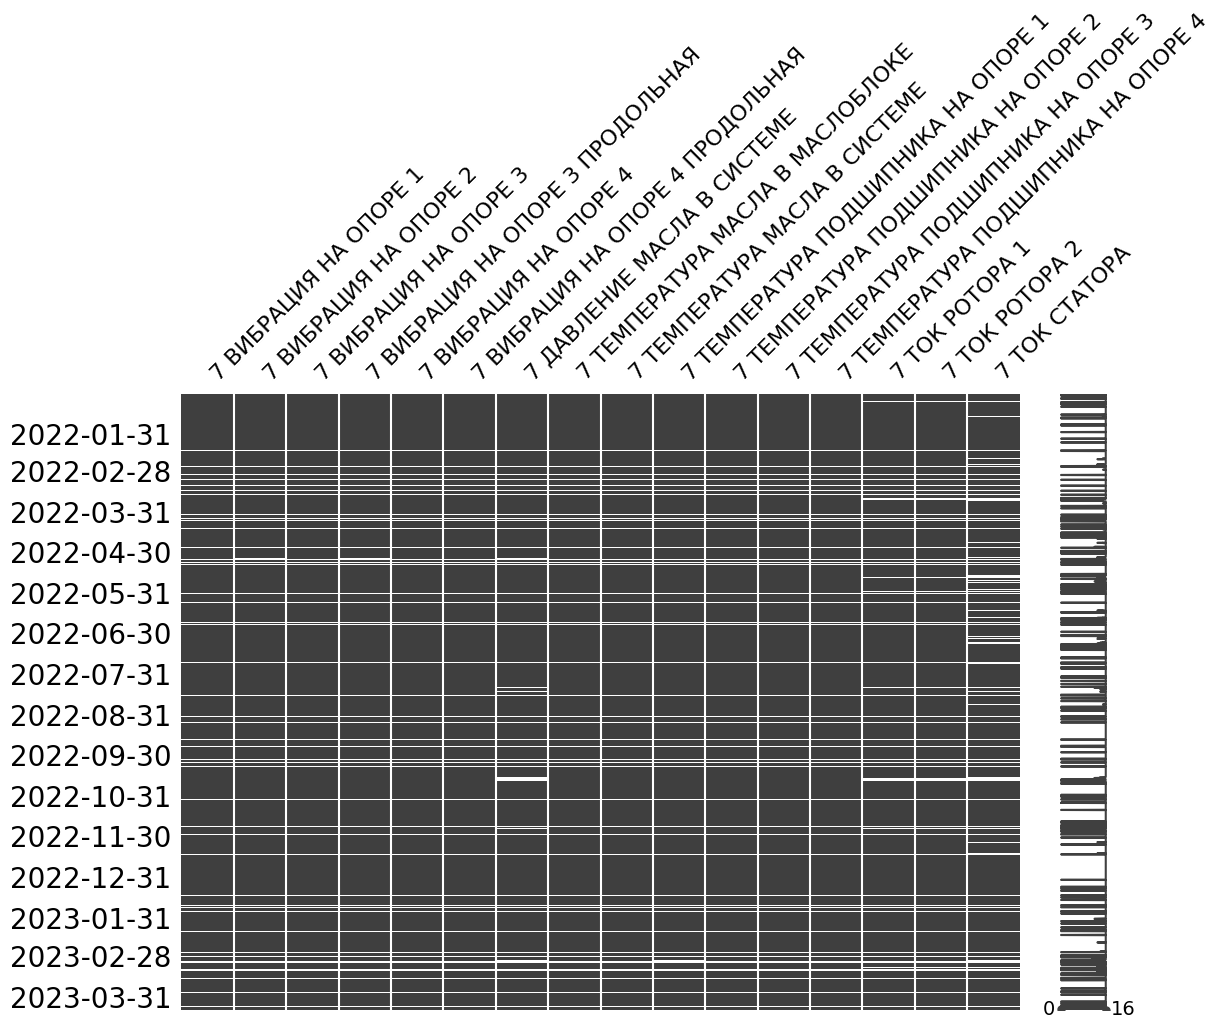

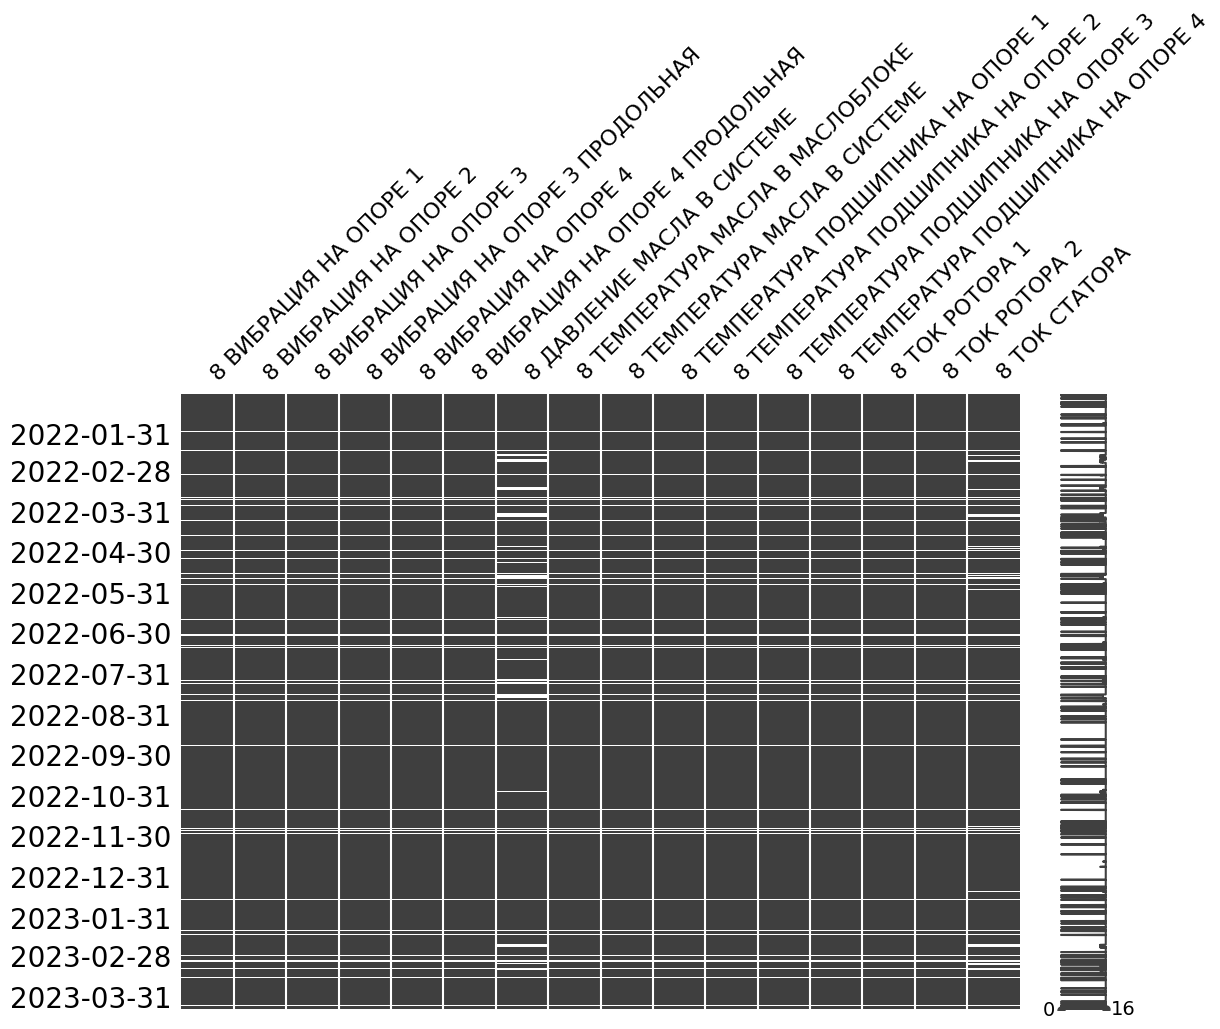

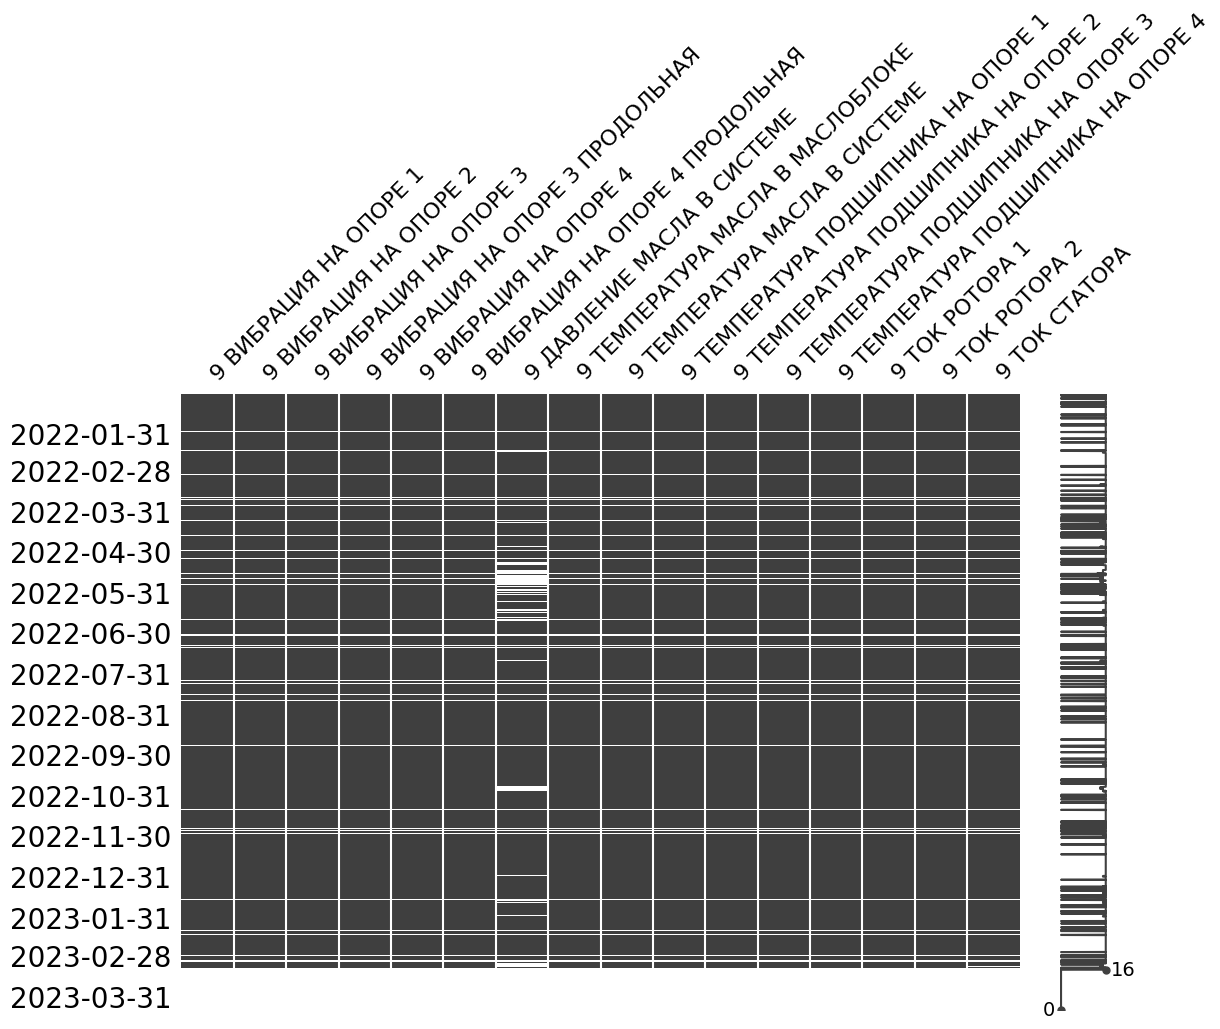

In [28]:
for equipment in range(4, 10):
  X_test = load_X(equipment, path=PATH, prefix='X_test').resample(freq).median()
  msno.matrix(X_test, freq='M', figsize=(12, 8));

### 2.3. Эталонные периоды для LSTM модели

In [29]:
ethalon_periods = select_ethalon_periods(messages, path=PATH)
ethalon_periods.columns = [col[2:] for col in X_train.columns] + ['equipment']

print(f'ethalon_periods.shape = {ethalon_periods.shape}\n')
ethalon_periods.head(2)

ethalon_periods.shape = (8162, 17)



,ВИБРАЦИЯ НА ОПОРЕ 1,ВИБРАЦИЯ НА ОПОРЕ 2,ВИБРАЦИЯ НА ОПОРЕ 3,ВИБРАЦИЯ НА ОПОРЕ 3 ПРОДОЛЬНАЯ,ВИБРАЦИЯ НА ОПОРЕ 4,ВИБРАЦИЯ НА ОПОРЕ 4 ПРОДОЛЬНАЯ,ДАВЛЕНИЕ МАСЛА В СИСТЕМЕ,ТЕМПЕРАТУРА МАСЛА В МАСЛОБЛОКЕ,ТЕМПЕРАТУРА МАСЛА В СИСТЕМЕ,ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 1,ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 2,ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 3,ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 4,ТОК РОТОРА 1,ТОК РОТОРА 2,ТОК СТАТОРА,equipment
dt,,,,,,,,,,,,,,,,,
2019-01-16 13:00:00,1.563937,0.737879,0.645386,1.629186,3.351842,0.744417,119.448131,40.319054,33.33406,41.457225,39.738215,39.953993,44.636200,360.921722,360.921722,243.680833,4
2019-01-16 14:00:00,1.557182,0.743087,0.638876,1.568169,2.738252,0.730758,119.764306,40.165818,33.05043,41.361075,39.622131,39.864005,44.536324,357.194764,357.194764,244.688722,4


In [30]:
ethalon_periods.iloc[:, :-1].describe().T

,count,mean,std,min,25%,50%,75%,max
ВИБРАЦИЯ НА ОПОРЕ 1,8162.0,1.510534,0.819428,0.025000,0.886667,1.213333,2.364875,5.387500
ВИБРАЦИЯ НА ОПОРЕ 2,8162.0,1.013187,0.847183,0.029900,0.556698,0.800000,1.010000,7.520000
ВИБРАЦИЯ НА ОПОРЕ 3,8162.0,1.365702,0.720291,0.033972,0.677281,1.388750,1.749792,4.659167
ВИБРАЦИЯ НА ОПОРЕ 3 ПРОДОЛЬНАЯ,8162.0,1.706995,0.793792,0.050000,1.146667,1.572078,2.327500,8.098319
ВИБРАЦИЯ НА ОПОРЕ 4,8162.0,1.030026,0.529443,0.050611,0.646719,1.058333,1.226667,3.491354
ВИБРАЦИЯ НА ОПОРЕ 4 ПРОДОЛЬНАЯ,8162.0,1.417060,0.876033,0.054500,0.730399,1.049167,1.896667,3.920000
ДАВЛЕНИЕ МАСЛА В СИСТЕМЕ,8162.0,160.071826,35.166159,0.000000,134.487556,166.930839,175.823451,266.331000
ТЕМПЕРАТУРА МАСЛА В МАСЛОБЛОКЕ,8162.0,34.109534,7.342469,0.324000,29.090328,35.426250,38.940000,53.989000
ТЕМПЕРАТУРА МАСЛА В СИСТЕМЕ,8162.0,24.085842,10.502587,0.000000,15.955833,25.352500,32.315000,44.026320
ТЕМПЕРАТУРА ПОДШИПНИКА НА ОПОРЕ 1,8162.0,43.517676,8.019684,0.000000,40.236000,44.851036,48.676667,72.605000


n_components = 3
explained_variance = 0.864
variance explained by 3 components:  0.596 0.171 0.096 



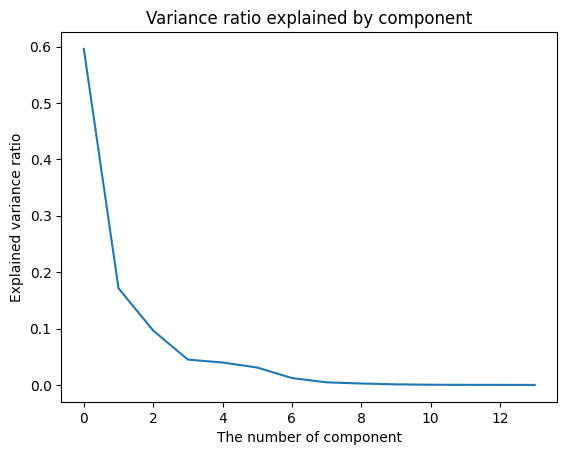

In [31]:
df, scaler, pca = get_pca_components(ethalon_periods, plot=True)

[Hotelling's T-Squared & Q residuals](https://wiki.eigenvector.com/index.php?title=T-Squared_Q_residuals_and_Contributions)

In [32]:
df.head(2)

,0,1,2,Hotelling's T-squared,Q residuals,equipment
dt,,,,,,
2019-01-16 13:00:00,-0.988189,0.345751,-2.726740,3.577084,16.641088,4
2019-01-16 14:00:00,-0.861942,0.575467,-2.257506,2.532197,10.083960,4


In [33]:
ethalon_dataset, scaler, pca = generate_ethalon_dataset(
    messages, path=PATH, plot=False,
)
ethalon_dataset.shape

(7062, 50, 5)

### 2.4. Неплановые остановки

In [34]:
M1_dataset, M1_labels = get_M1_dataset(
    scaler,
    pca,
    messages,
    path=PATH
)
M1_dataset.shape, len(M1_labels)

((61, 23, 5), 61)

### 2.5. Аномалии

In [35]:
def plot_anomalies(y):
  a = y.sum(axis=0)
  msno.matrix(y.loc[:, a[a > 0].index.tolist()], freq='BQ', figsize=(15, 6));

#### Эксгаустер 4


---------- Эксгаустер 4 ----------
M3_dataset.shape = (17890, 50, 16)


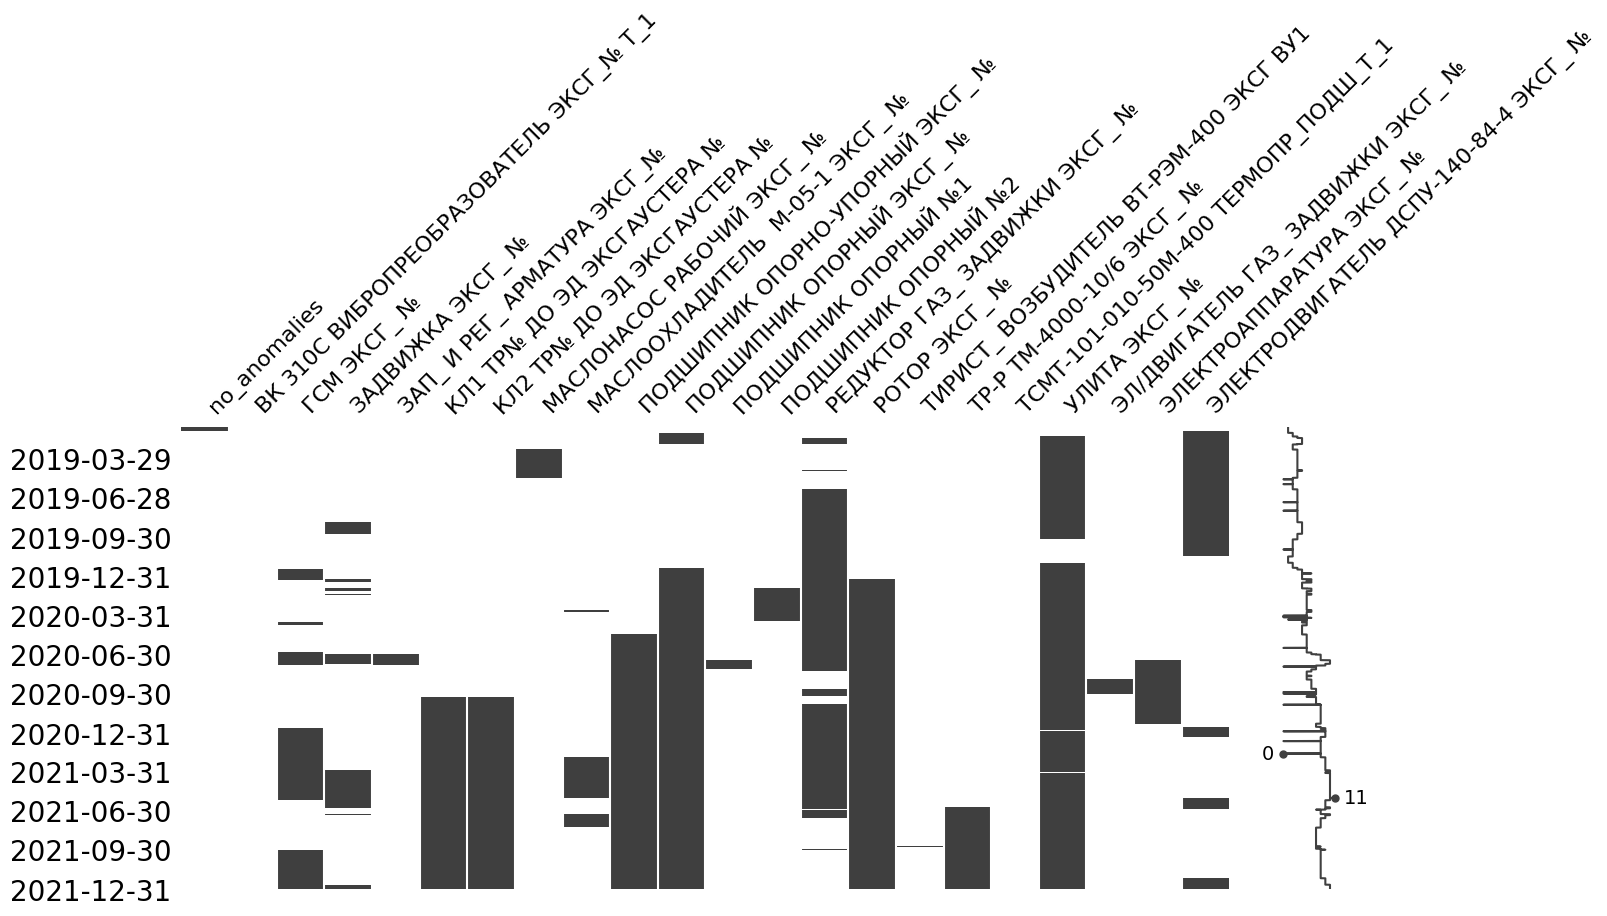

In [36]:
equipment = 4
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

#### Эксгаустер 5

---------- Эксгаустер 5 ----------
M3_dataset.shape = (25201, 50, 16)


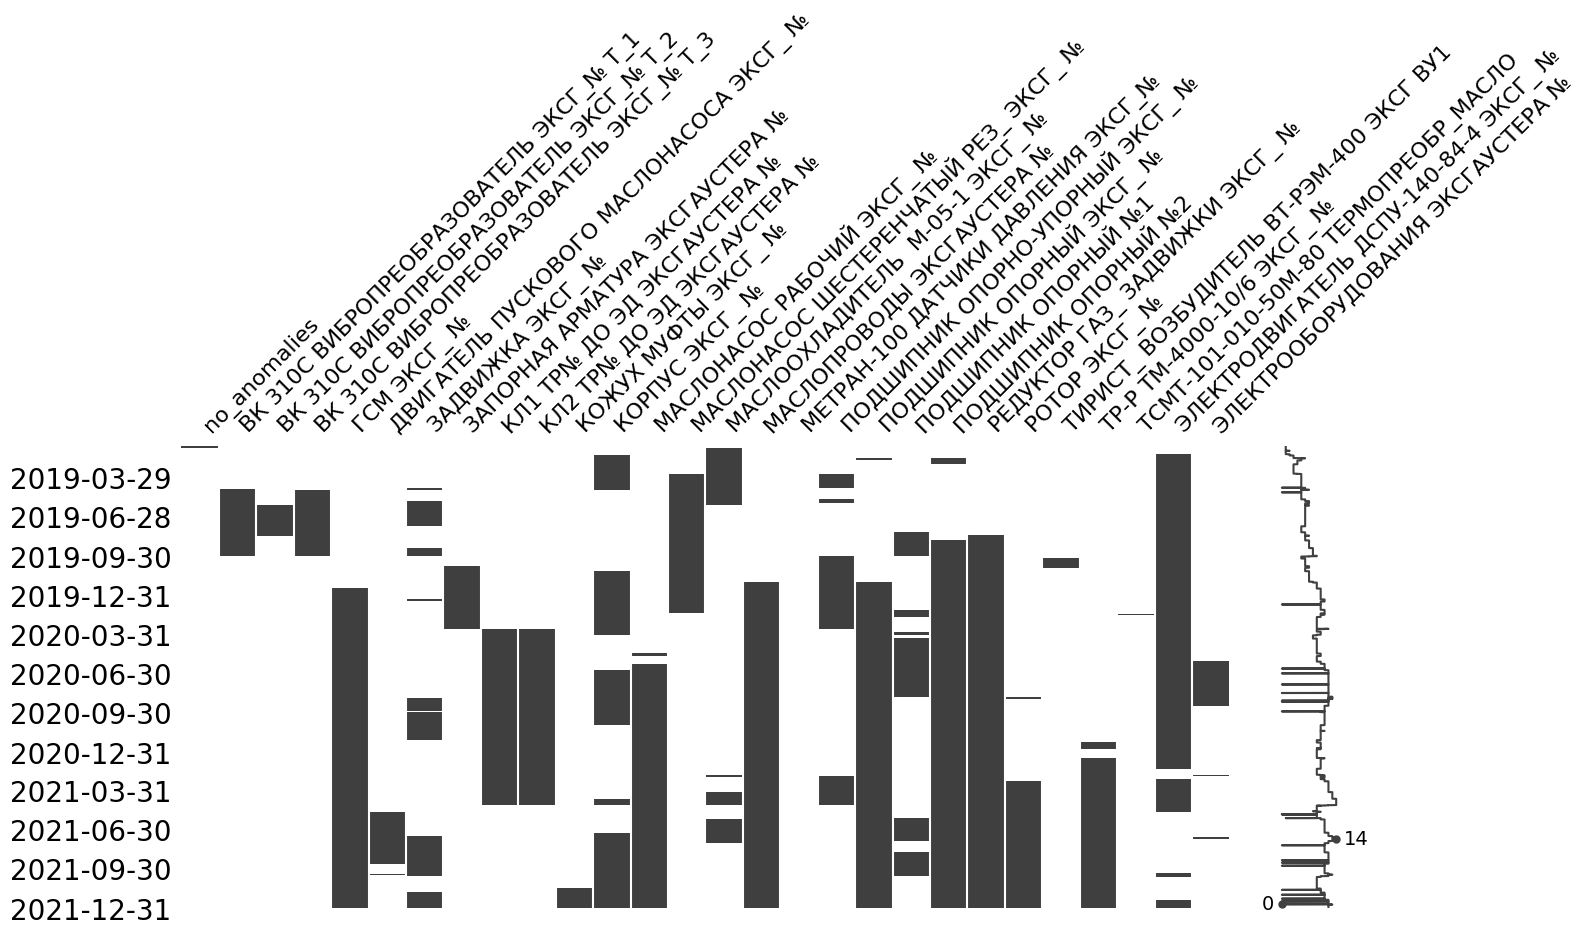

In [37]:
equipment = 5
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

#### Эксгаустер 6

---------- Эксгаустер 6 ----------
M3_dataset.shape = (19576, 50, 16)


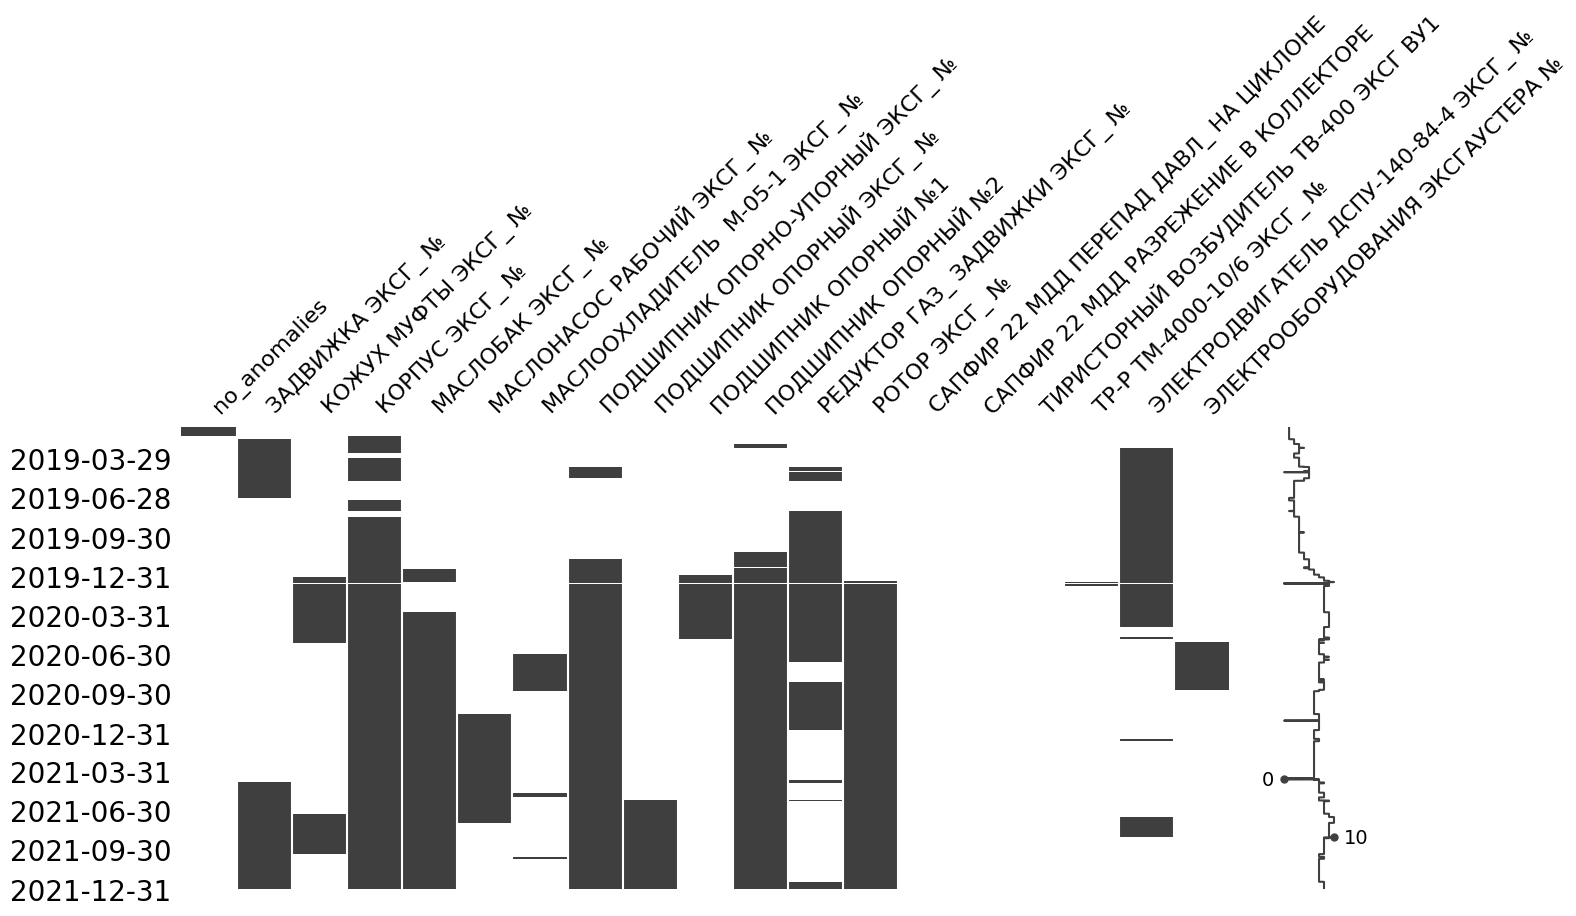

In [38]:
equipment = 6
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

#### Эксгаустер 7

---------- Эксгаустер 7 ----------
M3_dataset.shape = (19018, 50, 16)


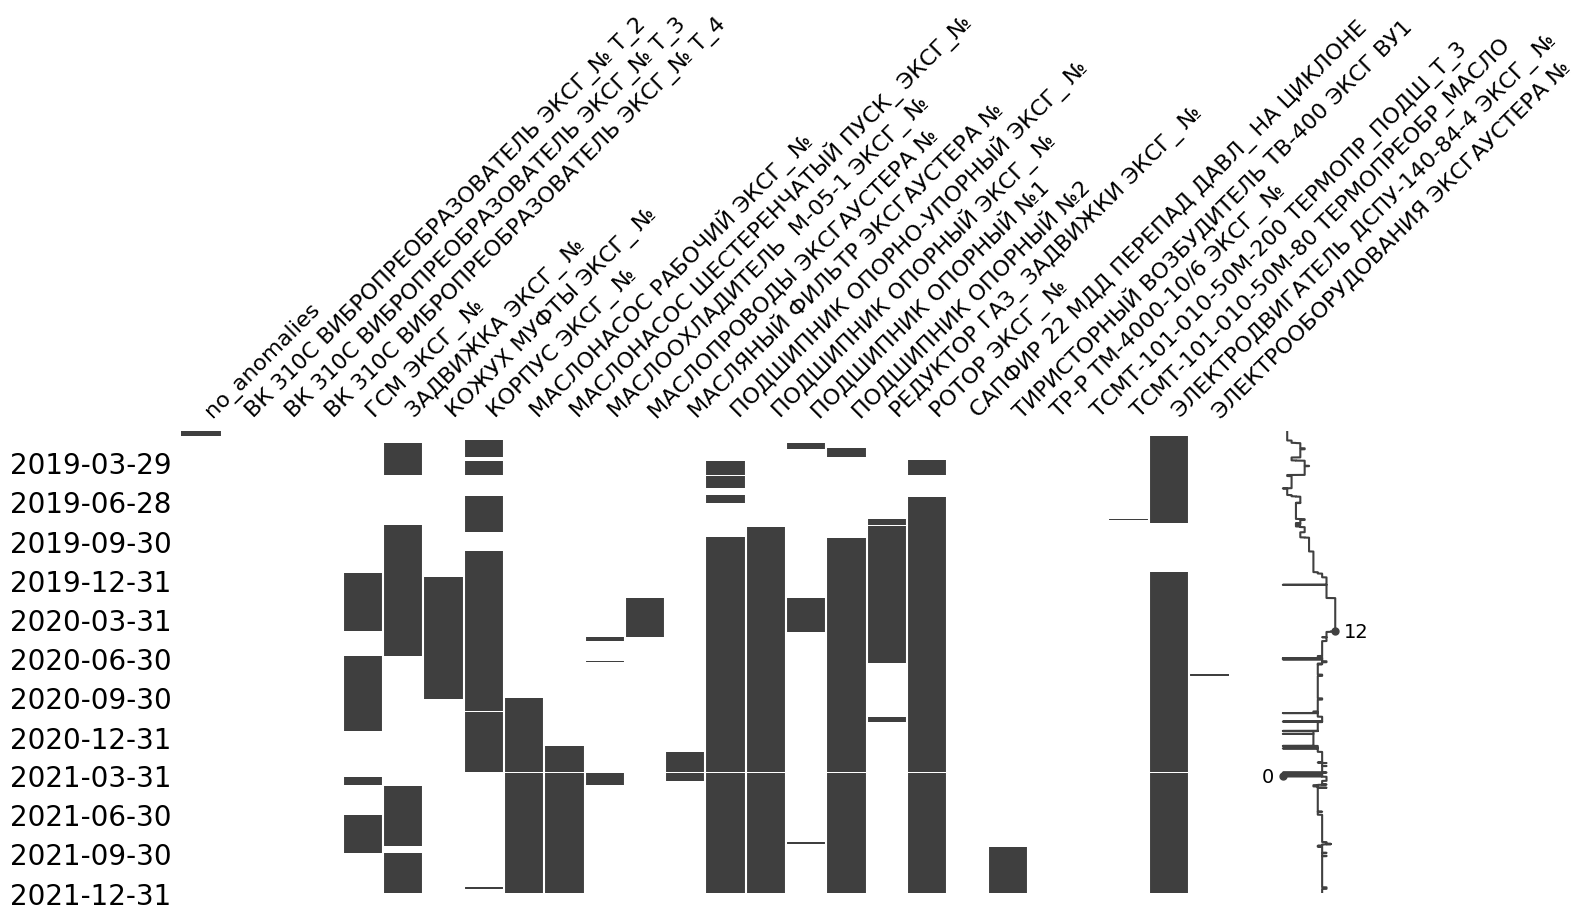

In [39]:
equipment = 7
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

#### Эксгаустер 8

---------- Эксгаустер 8 ----------
M3_dataset.shape = (24268, 50, 16)


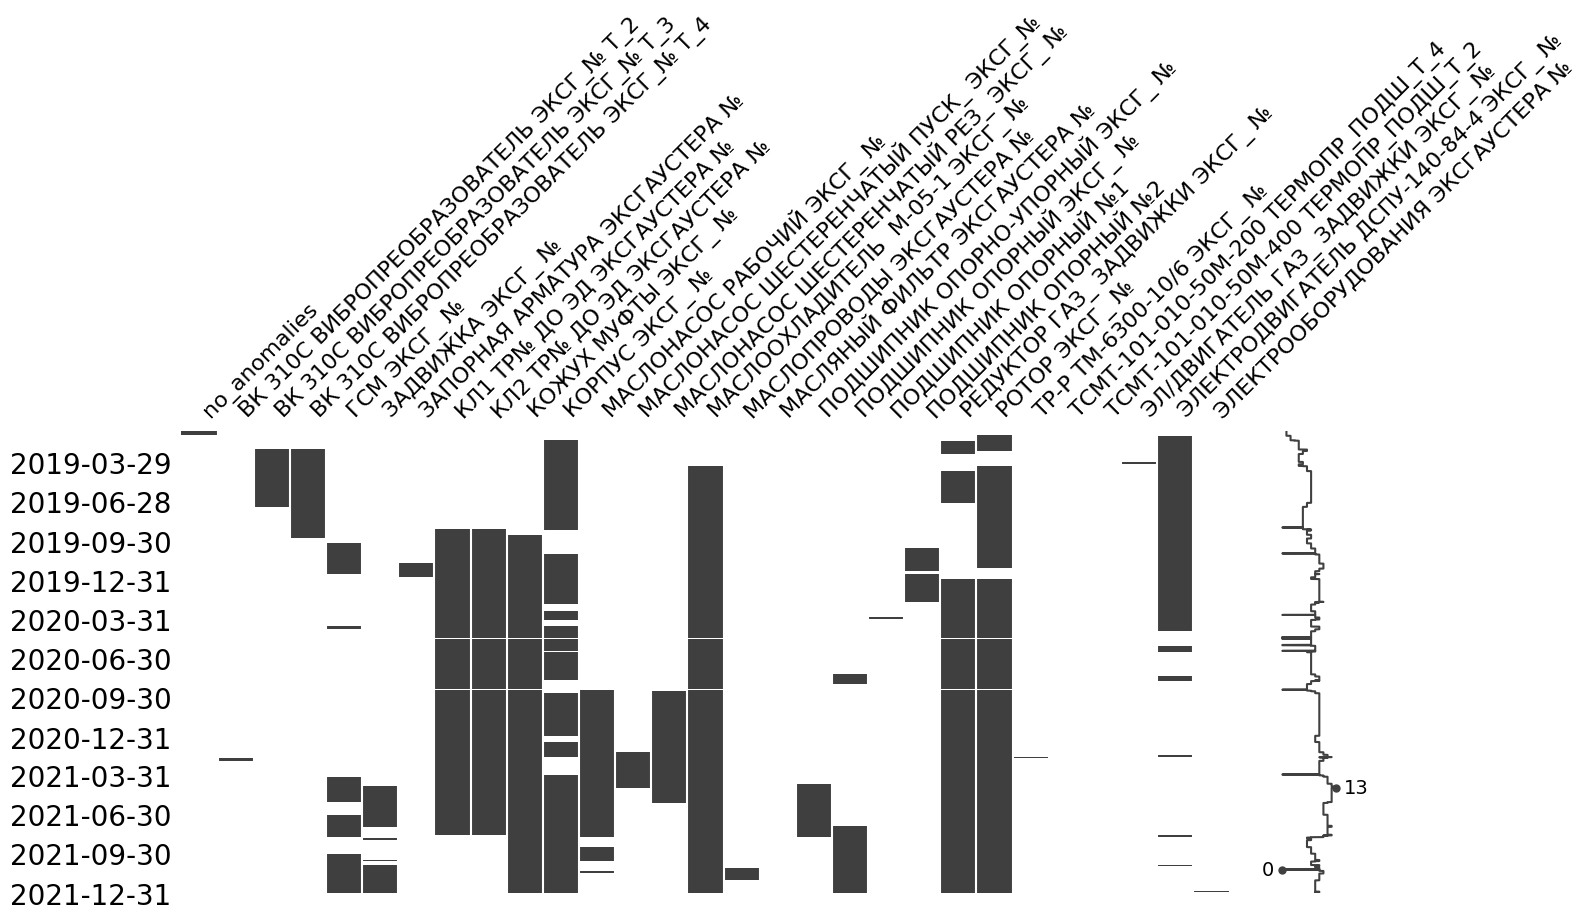

In [40]:
equipment = 8
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

#### Эксгаустер 9

---------- Эксгаустер 9 ----------
M3_dataset.shape = (25804, 50, 16)


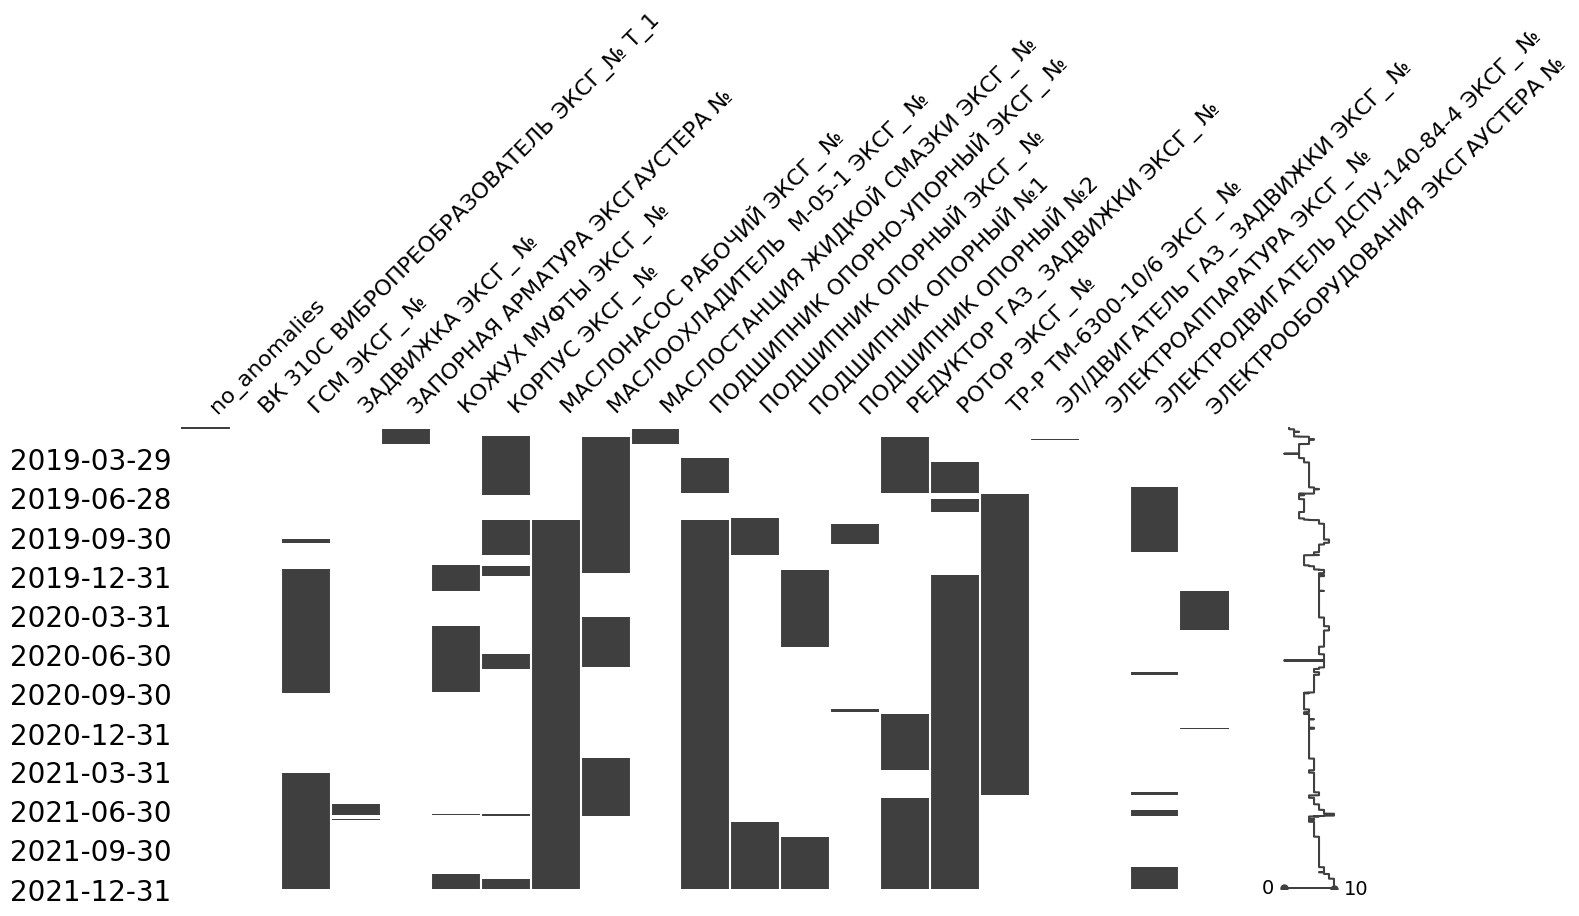

In [41]:
equipment = 9
M3_dataset = get_M3_dataset(equipment, messages, path=PATH,)
print(f'---------- Эксгаустер {equipment} ----------')
print(f'M3_dataset.shape = {M3_dataset.shape}')

y = generate_targets(equipment, messages)
plot_anomalies(y)

### 2.6. Тестовая выборка

В наборе сигналов тестовой выборки (X_test) присутствуют интервалы с пропущенными значениями. Список интервалов предоставлен в test_intervals. Для этих интервалов необходимо предсказать наличие неисправности.

В случае предсказанной неисправности, определить тип и время начала развития и наступления неисправности.


In [42]:
test_intervals = test_intervals.sort_values(by='start').reset_index(drop=True)
print(f'test_intervals.shape = {test_intervals.shape}\n')
test_intervals.head()

test_intervals.shape = (189, 4)



,start,finish,machine,tm
0,2022-01-01 10:54:53,2022-01-01 16:43:39,NaN,NaN
1,2022-01-02 12:26:42,2022-01-02 15:16:06,NaN,NaN
2,2022-01-04 12:06:07,2022-01-04 15:04:34,NaN,NaN
3,2022-01-04 20:13:57,2022-01-05 00:19:40,NaN,NaN
4,2022-01-07 09:05:16,2022-01-07 14:05:15,NaN,NaN


In [43]:
test_intervals['start'].min(), test_intervals['finish'].max()

(Timestamp('2022-01-01 10:54:53'), Timestamp('2023-04-20 23:58:07'))

In [44]:
(test_intervals['finish'] - test_intervals['start']).describe()

count                          189
mean     0 days 04:59:35.428571428
std      0 days 03:06:42.587346539
min                0 days 02:42:34
25%                0 days 03:38:37
50%                0 days 04:13:31
75%                0 days 05:05:08
max                1 days 00:58:29
dtype: object

Тестовый период - с 01.01.2022 по 20.04.2023 включительно. В среднем, интервал предсказания составляет 5 часов, медиана - 4 часа 13 минут. Максимальный горизонт предсказания - 25 часов.

#### 2.6.1. Объединение тестовых интервалов.

* Случаи, когда текущий период заканчивается раньше предыдущего.

In [45]:
for i in range(1, len(test_intervals)):
  t_start_prev = test_intervals.loc[i-1, 'start']
  t_end_prev = test_intervals.loc[i-1, 'finish']

  t_start = test_intervals.loc[i, 'start']
  t_end = test_intervals.loc[i, 'finish']

  if t_end_prev >= t_end:
    print(f'time difference:   {t_end_prev - t_start}  t_end_prev: {t_end_prev} t_start: {t_start}')
    print(f'new period length: {t_end_prev - t_start_prev}\n')

time difference:   0 days 03:57:38  t_end_prev: 2022-11-22 05:38:25 t_start: 2022-11-22 01:40:47
new period length: 0 days 04:22:54

time difference:   0 days 05:08:31  t_end_prev: 2023-01-10 14:08:44 t_start: 2023-01-10 09:00:13
new period length: 0 days 06:10:21



* Случаи, когда тестовый период начинается до окончания предыдущего, а заканчивается после.

In [46]:
for i in range(1, len(test_intervals)):
  t_start_prev = test_intervals.loc[i-1, 'start']
  t_end_prev = test_intervals.loc[i-1, 'finish']

  t_start = test_intervals.loc[i, 'start']
  t_end = test_intervals.loc[i, 'finish']

  if (t_start < t_end_prev) & (t_end_prev < t_end): #<= pd.Timedelta(23, 'H'):
    print(f'time difference:   {t_end_prev - t_start}  t_end_prev: {t_end_prev} t_start: {t_start}')
    print(f'new period length: {t_end - t_start_prev}\n')

time difference:   0 days 02:39:29  t_end_prev: 2022-06-22 06:41:29 t_start: 2022-06-22 04:02:00
new period length: 0 days 16:25:46

time difference:   0 days 00:08:29  t_end_prev: 2022-07-10 10:07:27 t_start: 2022-07-10 09:58:58
new period length: 0 days 08:05:33

time difference:   0 days 00:00:06  t_end_prev: 2022-09-01 07:33:38 t_start: 2022-09-01 07:33:32
new period length: 0 days 13:33:52

time difference:   0 days 01:14:30  t_end_prev: 2023-01-10 13:30:37 t_start: 2023-01-10 12:16:07
new period length: 0 days 07:28:58



* Объединим тестовые интервалы.

In [47]:
test_intervals = combine_test_intervals(test_intervals)
test_intervals.shape

(183, 4)

#### 2.6.2. Пропуски в данных для инференса.

In [48]:
len_input_period = 23
input_period = pd.Timedelta(len_input_period, "H")

s = 0
for i in range(1, len(test_intervals)):
  if test_intervals.loc[i, 'start'] - input_period < test_intervals.loc[i-1, 'finish']:
    s += 1
s

64

В тестовых интервалах в 64 случаях из 183 периоды, для которых нужно сделать предсказания, одновременно являются входящими периодами для LSTM модели на инференсе.

#### 2.6.3. Интервалы за пределами горизонта предсказания модели.

In [49]:
equipment = 4
freq = "1H"
input_period = pd.Timedelta(23, "H")
X_test = load_X(equipment, path=PATH, prefix="X_test").resample(freq).median()

for t1  in test_intervals['start']:
  t0 = t1 - input_period
  a = X_test.loc[t0:t1, :]
  if a.shape[0] != input_period // pd.Timedelta(freq):
    print(f'{t1} {a.shape}')

2022-01-01 10:54:53 (11, 16)
2023-04-10 18:08:25 (5, 16)
2023-04-18 02:28:43 (0, 16)
2023-04-20 16:41:58 (0, 16)


Предсказания на интервалы после 2023-04-10 18:00 в рамках почасовой модели делаться не будут. Для них будет разработана подневная модель.

In [50]:
all_test_periods = generate_test_dataset(test_intervals, path=PATH)

for equipment in range(4, 10):
  print(all_test_periods[equipment].shape)

(179, 23, 16)
(179, 23, 16)
(179, 23, 16)
(179, 23, 16)
(179, 23, 16)
(179, 23, 16)
